# Load Libraries and Data

In [1]:
!pip install tab-transformer-pytorch torch

# Load libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, classification_report

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold, train_test_split, ParameterGrid
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from tab_transformer_pytorch import FTTransformer

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

file_path = "/content/drive/MyDrive/Master thesis/merged_artists.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (101226, 46)


,Artist Name,Country,Genre,Label,Viberate Rank,Spotify Rank,Spotify Followers Total,Spotify Streams Total,Spotify Monthly Listeners Total,Spotify Playlist Reach Total,...,Instagram Likes 1m,Facebook Followers 1m,Deezer Fans 1m,SoundCloud Followers 1m,SoundCloud Plays 1m,Shazam Shazams 1m,Radio Airplay Spins 1m,Radio Airplay Countries with Spins 1m,Radio Airplay Stations with Spins 1m,Beatport Track Performance Points 1m
0,Moliy,Ghana,African,"Big Indie Labels, Sony Music Entertainment, Un...",1297.0,1201.0,259373.0,1.160112e+09,11951295.0,86354352.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,amaarae,Ghana,R&B,"Universal Music Group, Warner Music Group, Son...",4589.0,2714.0,610701.0,1.376583e+09,5259973.0,36449115.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Blaqbonez,Nigeria,Hip Hop,"Big Indie Labels, Universal Music Group, Warne...",6535.0,7528.0,1281464.0,3.472101e+08,1412483.0,8119279.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fimiguerrero,United Kingdom,Hip Hop,"Big Indie Labels, Sony Music Entertainment, Un...",6940.0,6265.0,174136.0,2.475404e+08,3298359.0,7569899.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Poco Lee,Nigeria,African,"Big Indie Labels, Warner Music Group",8522.0,14398.0,376708.0,6.108530e+07,855002.0,1753597.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Preprocessing

## Data Cleaning

In [3]:
def clean_raw_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Standardize column names
    df.columns = df.columns.str.strip()

    # Clean string columns without turning NaN into "nan"
    obj_cols = df.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        df[c] = df[c].apply(lambda x: x.strip() if isinstance(x, str) else x)

    # Parse multi-label columns
    for col in ["Genre", "Label"]:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: [] if pd.isna(x) else [v.strip() for v in str(x).split(",") if v.strip()]
            )

    return df

### Duplicated Data

In [4]:
def aggregate_artist_country(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["Artist Name"] = df["Artist Name"].replace("", pd.NA)
    df["Country"] = df["Country"].replace("", pd.NA)
    df = df.dropna(subset=["Artist Name", "Country"]).copy()

    rank_cols = [c for c in df.columns if "Rank" in c]
    total_cols = [c for c in df.columns if c.endswith("Total")]
    one_month_cols = [c for c in df.columns if c.endswith("1m")]

    numeric_cols = list(set(rank_cols + total_cols + one_month_cols))
    df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

    df["momentum_spotify"] = (
        df["Spotify Streams 1m"] / (df["Spotify Streams Total"] + 1)
    )

    agg_dict = {
        **{c: "max" for c in total_cols + one_month_cols},
        **{c: "min" for c in rank_cols},
        "momentum_spotify": "median"
    }

    if "Genre" in df.columns:
        agg_dict["Genre"] = lambda s: sorted(set(v for lst in s for v in (lst if isinstance(lst, list) else [])))

    if "Label" in df.columns:
        agg_dict["Label"] = lambda s: sorted(set(v for lst in s for v in (lst if isinstance(lst, list) else [])))

    return df.groupby(["Artist Name", "Country"], as_index=False).agg(agg_dict)

### Target Creation

In [5]:
def create_target(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df = df.dropna(subset=["momentum_spotify"]).copy()

    thr = df["momentum_spotify"].quantile(0.80)
    df["emerging"] = (df["momentum_spotify"] >= thr).astype(int)

    return df

### Remove Leakage

In [6]:
def remove_leakage(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Remove Spotify features (used to build target)
    spotify_cols = [c for c in df.columns if "spotify" in c.lower()]
    df = df.drop(columns=spotify_cols, errors="ignore")

    # Remove ranks
    rank_cols = [c for c in df.columns if "rank" in c.lower()]
    df = df.drop(columns=rank_cols, errors="ignore")

    # Remove IDs
    df = df.drop(columns=["Artist Name"], errors="ignore")

    return df

### Missing Values

In [7]:
def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in ["Genre", "Label"]:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: x if isinstance(x, list) else [])

    metric_cols = [
        c for c in df.columns
        if (c.endswith("Total") or c.endswith("1m")) and "spotify" not in c.lower()
    ]

    df[metric_cols] = df[metric_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    return df

## Feature Engineering

In [8]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    def safe_ratio(num, den):
        num = pd.to_numeric(num, errors="coerce").fillna(0)
        den = pd.to_numeric(den, errors="coerce").fillna(0)
        return num / (den + 1)

    # YouTube
    df["youtube_sub_momentum"] = safe_ratio(
        df["YouTube Subscribers 1m"], df["YouTube Subscribers Total"]
    )
    df["youtube_view_momentum"] = safe_ratio(
        df["YouTube Views 1m"], df["YouTube Views Total"]
    )
    df["youtube_like_momentum"] = safe_ratio(
        df["YouTube Likes 1m"], df["YouTube Likes Total"]
    )
    df["youtube_like_rate_1m"] = safe_ratio(
        df["YouTube Likes 1m"], df["YouTube Views 1m"]
    )
    df["youtube_views_1m_per_subscriber_total"] = safe_ratio(
        df["YouTube Views 1m"], df["YouTube Subscribers Total"]
    )
    df["youtube_likes_1m_per_subscriber_total"] = safe_ratio(
        df["YouTube Likes 1m"], df["YouTube Subscribers Total"]
    )

    # TikTok
    df["tiktok_follower_momentum"] = safe_ratio(
        df["TikTok Followers 1m"], df["TikTok Followers Total"]
    )
    df["tiktok_like_rate_1m"] = safe_ratio(
        df["TikTok Likes 1m"], df["TikTok Views 1m"]
    )
    df["tiktok_views_1m_per_follower_total"] = safe_ratio(
        df["TikTok Views 1m"], df["TikTok Followers Total"]
    )
    df["tiktok_likes_1m_per_follower_total"] = safe_ratio(
        df["TikTok Likes 1m"], df["TikTok Followers Total"]
    )

    # Instagram
    df["instagram_follower_momentum"] = safe_ratio(
        df["Instagram Followers 1m"], df["Instagram Followers Total"]
    )
    df["instagram_likes_per_follower_1m"] = safe_ratio(
        df["Instagram Likes 1m"], df["Instagram Followers Total"]
    )

    # Facebook
    df["facebook_follower_momentum"] = safe_ratio(
        df["Facebook Followers 1m"], df["Facebook Followers Total"]
    )

    # Deezer
    df["deezer_fan_momentum"] = safe_ratio(
        df["Deezer Fans 1m"], df["Deezer Fans Total"]
    )

    # SoundCloud
    df["soundcloud_follower_momentum"] = safe_ratio(
        df["SoundCloud Followers 1m"], df["SoundCloud Followers Total"]
    )
    df["soundcloud_plays_per_follower_1m"] = safe_ratio(
        df["SoundCloud Plays 1m"], df["SoundCloud Followers Total"]
    )
    df["soundcloud_plays_per_new_follower_1m"] = safe_ratio(
        df["SoundCloud Plays 1m"], df["SoundCloud Followers 1m"]
    )

    # Radio
    df["radio_spins_per_station_1m"] = safe_ratio(
        df["Radio Airplay Spins 1m"], df["Radio Airplay Stations with Spins 1m"]
    )
    df["radio_countries_per_station_1m"] = safe_ratio(
        df["Radio Airplay Countries with Spins 1m"],
        df["Radio Airplay Stations with Spins 1m"]
    )
    df["radio_spins_per_country_1m"] = safe_ratio(
        df["Radio Airplay Spins 1m"], df["Radio Airplay Countries with Spins 1m"]
    )

    # Beatport
    df["beatport_points_momentum"] = safe_ratio(
        df["Beatport Track Performance Points 1m"],
        df["Beatport Track Performance Points Total"]
    )
    df["beatport_top100_share"] = safe_ratio(
        df["Beatport Tracks in Top 100 Total"], df["Beatport Tracks Total"]
    )
    df["beatport_days_per_top100_track"] = safe_ratio(
        df["Beatport Days in Top 100 Total"],
        df["Beatport Tracks in Top 100 Total"]
    )
    df["beatport_points_per_track_total"] = safe_ratio(
        df["Beatport Track Performance Points Total"], df["Beatport Tracks Total"]
    )

    # Presence score
    totals = [
        "YouTube Subscribers Total",
        "TikTok Followers Total",
        "Instagram Followers Total",
        "Facebook Followers Total",
        "Deezer Fans Total",
        "SoundCloud Followers Total",
        "Beatport Tracks Total"
    ]
    df["platform_presence_score"] = (df[totals].fillna(0) > 0).sum(axis=1)

    return df

# Train Test Split

In [9]:
def split_data(df: pd.DataFrame, target_col="emerging"):
    df = df.copy()

    X = df.drop(columns=[target_col])
    y = df[target_col]

    return train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

In [10]:
df_clean = clean_raw_data(df)
df_clean = aggregate_artist_country(df_clean)
df_clean = create_target(df_clean)
df_clean = remove_leakage(df_clean)
df_clean = handle_missing_values(df_clean)
df_clean = add_features(df_clean)

X_train, X_test, y_train, y_test = split_data(df_clean)

print(X_train.shape, X_test.shape)

(69702, 57) (17426, 57)


### Seperate Features

In [11]:
# Define platform groups
platform_patterns = {
    "YouTube": "youtube",
    "TikTok": "tiktok",
    "Instagram": "instagram",
    "Facebook": "facebook",
    "SoundCloud": "soundcloud",
    "Radio": "radio",
    "Beatport": "beatport",
    "Shazam": "shazam",
    "Deezer": "deezer"
}

def build_feature_sets(df, platform_patterns):
    # columns belonging to each platform
    platform_sets = {
        name: [c for c in df.columns if pattern in c.lower()]
        for name, pattern in platform_patterns.items()
    }

    # keep only platform-related columns
    all_platform_cols = [
        c for c in df.columns
        if any(pattern in c.lower() for pattern in platform_patterns.values())
    ]

    # final feature sets
    feature_sets = {
        "All_Platforms": all_platform_cols
    }

    for name, cols in platform_sets.items():
        if len(cols) > 0:
            feature_sets[name] = cols

    return feature_sets, platform_sets

feature_sets, platform_sets = build_feature_sets(X_train, platform_patterns)

for name, cols in feature_sets.items():
    bad = X_train[cols].select_dtypes(include=["object"]).columns.tolist()
    if bad:
        raise ValueError(f"{name} contains non-numeric columns: {bad}")

print(feature_sets.keys())

dict_keys(['All_Platforms', 'YouTube', 'TikTok', 'Instagram', 'Facebook', 'SoundCloud', 'Radio', 'Beatport', 'Shazam', 'Deezer'])


# Modeling

## DT

In [ ]:
def eval_dt(cols, name):
    if len(cols) == 0:
        return None

    Xtr = X_train[cols].copy()
    Xte = X_test[cols].copy()

    Xtr = Xtr.replace([np.inf, -np.inf], np.nan).fillna(0)
    Xte = Xte.replace([np.inf, -np.inf], np.nan).fillna(0)

    dt = DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42
    )

    dt.fit(Xtr, y_train)

    proba = dt.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)

    return {
        "Model": name,
        "n_features": len(cols),
        "F1": f1_score(y_test, pred, zero_division=0),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, proba),
        "fitted_model": dt,
        "feature_names": cols
    }

results = []

for name, cols in feature_sets.items():
    res = eval_dt(cols, name)
    if res is not None:
        results.append(res)

# Results table sorted by F1
results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "n_features": r["n_features"],
        "F1": r["F1"],
        "Precision": r["Precision"],
        "Recall": r["Recall"],
        "ROC_AUC": r["ROC_AUC"]
    }
    for r in results
]).sort_values("F1", ascending=False)

display(results_df)

,Model,n_features,F1,Precision,Recall,ROC_AUC
0,All_Platforms,53,0.540412,0.447477,0.682066,0.802508
1,YouTube,12,0.481004,0.349707,0.770158,0.761155
9,Deezer,3,0.478963,0.361249,0.710473,0.751334
4,Facebook,3,0.434484,0.317109,0.689813,0.687925
6,Radio,6,0.398260,0.293909,0.617504,0.664506
5,SoundCloud,6,0.375440,0.252091,0.735151,0.653468
7,Beatport,9,0.362257,0.226075,0.911047,0.577278
8,Shazam,1,0.333317,0.199989,1.000000,0.500000
3,Instagram,5,0.321493,0.218221,0.610330,0.545643
2,TikTok,8,0.280403,0.310863,0.255380,0.561242


In [ ]:
# Best DT based on F1
best_dt_result = max(results, key=lambda x: x["F1"])

best_dt_model = best_dt_result["fitted_model"]
best_dt_features = best_dt_result["feature_names"]

feature_importance_df = pd.DataFrame({
    "Feature": best_dt_features,
    "Importance": best_dt_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance_df = feature_importance_df[feature_importance_df["Importance"] > 0]

print("Best DT model:", best_dt_result["Model"])
display(feature_importance_df.head(20))

Best DT model: All_Platforms


,Feature,Importance
30,youtube_view_momentum,0.413850
6,Deezer Fans Total,0.223872
42,deezer_fan_momentum,0.193667
5,Facebook Followers Total,0.073140
26,Radio Airplay Countries with Spins 1m,0.034380
1,YouTube Views Total,0.023051
41,facebook_follower_momentum,0.022699
12,YouTube Subscribers 1m,0.015341


[[11006  2935]
 [ 1108  2377]]


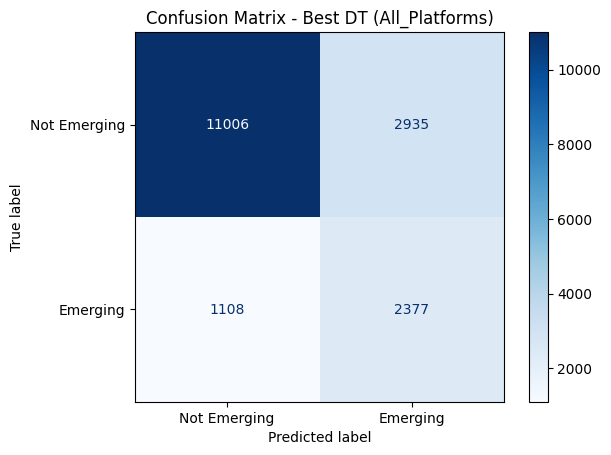

In [ ]:
# Recreate test set for the best DT
X_test_best_dt = X_test[best_dt_features].copy()
X_test_best_dt = X_test_best_dt.replace([np.inf, -np.inf], np.nan).fillna(0)

# Predicted probabilities and class predictions
dt_test_proba = best_dt_model.predict_proba(X_test_best_dt)[:, 1]
dt_test_pred = (dt_test_proba >= 0.5).astype(int)   # same threshold as before

# Confusion matrix
cm = confusion_matrix(y_test, dt_test_pred)

print(cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Emerging", "Emerging"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - Best DT ({best_dt_result['Model']})")
plt.show()

## RF

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def screen_rf_feature_set(cols, name):
    if not cols:
        return None

    Xtr = X_train[cols].copy()
    Xtr = Xtr.replace([np.inf, -np.inf], np.nan).fillna(0)

    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        rf,
        Xtr,
        y_train,
        cv=cv,
        scoring=["f1", "precision", "recall", "roc_auc"],
        n_jobs=1
    )

    return {
        "Model": name,
        "n_features": len(cols),
        "CV_F1": scores["test_f1"].mean(),
        "CV_Precision": scores["test_precision"].mean(),
        "CV_Recall": scores["test_recall"].mean(),
        "CV_ROC_AUC": scores["test_roc_auc"].mean()
    }

# Screen feature sets
screening_results = []

for name, cols in feature_sets.items():
    res = screen_rf_feature_set(cols, name)
    if res is not None:
        screening_results.append(res)

screening_df = (
    pd.DataFrame(screening_results)
    .sort_values("CV_F1", ascending=False)
    .round(3)
)

display(screening_df)

# Best feature set based on CV_F1
best_name = screening_df.iloc[0]["Model"]
best_cols = feature_sets[best_name]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,n_features,CV_F1,CV_Precision,CV_Recall,CV_ROC_AUC
0,All_Platforms,53,0.575,0.479,0.721,0.844
1,YouTube,12,0.481,0.358,0.732,0.771
9,Deezer,3,0.476,0.363,0.692,0.752
4,Facebook,3,0.434,0.319,0.678,0.691
6,Radio,6,0.396,0.287,0.637,0.669
5,SoundCloud,6,0.381,0.255,0.757,0.661
7,Beatport,9,0.367,0.230,0.914,0.592
3,Instagram,5,0.320,0.231,0.524,0.563
2,TikTok,8,0.293,0.313,0.276,0.574
8,Shazam,1,0.200,0.120,0.600,0.500


In [21]:
# Prepare best feature set
X_best = X_train[best_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(0)

X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_best,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
    RandomizedSearchCV
)
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Hyperparameter tuning
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_leaf": [10, 20, 50],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", 0.5],
    "class_weight": ["balanced"]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=1
)

rf_search.fit(X_subtrain, y_subtrain)

print("Best params:", rf_search.best_params_)
print("Best CV F1:", round(rf_search.best_score_, 3))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 20, 'max_features': 0.5, 'max_depth': None, 'class_weight': 'balanced'}
Best CV F1: 0.587


In [23]:
# Threshold tuning on validation
best_rf = rf_search.best_estimator_
val_proba = best_rf.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
best_thr = 0.5
best_f1 = -1

for thr in thresholds:
    val_pred = (val_proba >= thr).astype(int)
    score = f1_score(y_val, val_pred, zero_division=0)
    if score > best_f1:
        best_f1 = score
        best_thr = thr

print("Best threshold:", round(best_thr, 2))
print("Validation F1:", round(best_f1, 3))


Best threshold: 0.55
Validation F1: 0.595


In [24]:
# Refit final model on full training data with best params
X_best_full = X_train[best_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(0)

rf_final = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_best_full, y_train)

RandomForestClassifier(class_weight='balanced', max_features=0.5,
                       min_samples_leaf=20, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [25]:
# Final test evaluation
X_test_best = X_test[best_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(0)

test_proba = rf_final.predict_proba(X_test_best)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

final_results = {
    "Model": best_name,
    "n_features": len(best_cols),
    "Threshold": round(best_thr, 2),
    "Test_F1": f1_score(y_test, test_pred, zero_division=0),
    "Test_Precision": precision_score(y_test, test_pred, zero_division=0),
    "Test_Recall": recall_score(y_test, test_pred, zero_division=0),
    "Test_ROC_AUC": roc_auc_score(y_test, test_proba)
}

print(final_results)

{'Model': 'All_Platforms', 'n_features': 53, 'Threshold': np.float64(0.55), 'Test_F1': 0.6073955413162462, 'Test_Precision': 0.5678981527708438, 'Test_Recall': 0.6527977044476327, 'Test_ROC_AUC': np.float64(0.8605954052932849)}


In [27]:
# Feature importance for the final RF model
rf_feature_importance = pd.DataFrame({
    "feature": X_best_full.columns,
    "importance": rf_final.feature_importances_
}).sort_values(by="importance", ascending=False)

print(rf_feature_importance.head(20))

                                  feature  importance
30                  youtube_view_momentum    0.205556
6                       Deezer Fans Total    0.110191
42                    deezer_fan_momentum    0.109964
31                  youtube_like_momentum    0.050937
5                Facebook Followers Total    0.044775
33  youtube_views_1m_per_subscriber_total    0.039573
26  Radio Airplay Countries with Spins 1m    0.038477
4               Instagram Followers Total    0.025977
29                   youtube_sub_momentum    0.022827
27   Radio Airplay Stations with Spins 1m    0.022492
13                       YouTube Views 1m    0.021003
41             facebook_follower_momentum    0.019945
1                     YouTube Views Total    0.017775
46             radio_spins_per_station_1m    0.016983
43           soundcloud_follower_momentum    0.016775
47         radio_countries_per_station_1m    0.016271
21                         Deezer Fans 1m    0.015909
12                 YouTube S

[[12210  1731]
 [ 1210  2275]]


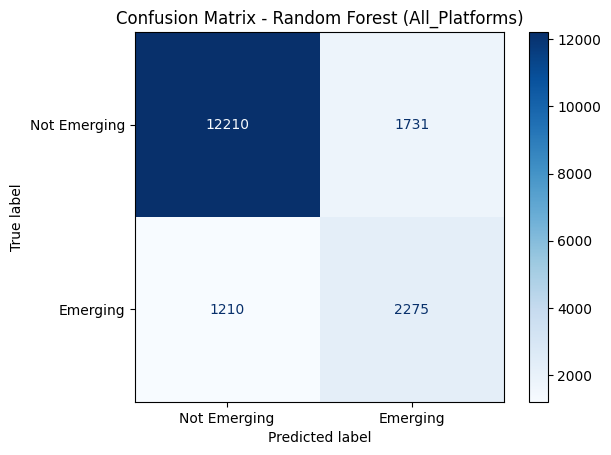

In [ ]:
# Confusion matrix for final RF
cm = confusion_matrix(y_test, test_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Emerging", "Emerging"]
)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - Random Forest ({best_name})")
plt.show()

## XGB

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
    RandomizedSearchCV
)
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

## XGB

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def screen_xgb_feature_set(cols, name):
    if not cols:
        return None

    Xtr = X_train[cols].copy()
    Xtr = Xtr.replace([np.inf, -np.inf], np.nan).fillna(0)

    xgb = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=0,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        importance_type="gain"
    )

    scores = cross_validate(
        xgb,
        Xtr,
        y_train,
        cv=cv,
        scoring=["f1", "precision", "recall", "roc_auc"],
        n_jobs=1
    )

    return {
        "Model": name,
        "n_features": len(cols),
        "CV_F1": scores["test_f1"].mean(),
        "CV_Precision": scores["test_precision"].mean(),
        "CV_Recall": scores["test_recall"].mean(),
        "CV_ROC_AUC": scores["test_roc_auc"].mean()
    }

# Screen feature sets
screening_results = []

for name, cols in feature_sets.items():
    res = screen_xgb_feature_set(cols, name)
    if res is not None:
        screening_results.append(res)

screening_df = (
    pd.DataFrame(screening_results)
    .sort_values("CV_F1", ascending=False)
    .round(3)
)

display(screening_df)

# Best feature set based on CV_F1
best_name = screening_df.iloc[0]["Model"]
best_cols = feature_sets[best_name]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

,Model,n_features,CV_F1,CV_Precision,CV_Recall,CV_ROC_AUC
0,All_Platforms,53,0.572,0.463,0.749,0.849
1,YouTube,12,0.481,0.352,0.757,0.772
9,Deezer,3,0.476,0.365,0.684,0.754
4,Facebook,3,0.434,0.318,0.684,0.692
6,Radio,6,0.397,0.284,0.655,0.668
5,SoundCloud,6,0.381,0.253,0.772,0.662
7,Beatport,9,0.367,0.230,0.917,0.593
3,Instagram,5,0.321,0.232,0.524,0.562
2,TikTok,8,0.298,0.303,0.294,0.577
8,Shazam,1,0.067,0.040,0.200,0.500


In [ ]:
# Prepare best feature set
X_best = X_train[best_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(0)

X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_best,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [ ]:
# Hyperparameter tuning on F1
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 1],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 3, 5, 10]
}

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    importance_type="gain"
)

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_subtrain, y_subtrain)

print("Best params:", xgb_search.best_params_)
print("Best CV F1:", round(xgb_search.best_score_, 3))

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best CV F1: 0.593


In [ ]:
# Threshold tuning on validation set using F1
best_xgb = xgb_search.best_estimator_
val_proba = best_xgb.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)
best_thr = 0.5
best_f1 = -1

for thr in thresholds:
    val_pred = (val_proba >= thr).astype(int)
    score = f1_score(y_val, val_pred, zero_division=0)
    if score > best_f1:
        best_f1 = score
        best_thr = thr

print("Best threshold:", round(best_thr, 2))
print("Validation F1:", round(best_f1, 3))

Best threshold: 0.59
Validation F1: 0.595


In [ ]:
# Refit final model on full training data
X_best_full = X_train[best_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(0)

xgb_final = XGBClassifier(
    **xgb_search.best_params_,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    importance_type="gain"
)

xgb_final.fit(X_best_full, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type='gain',
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Final test evaluation
X_test_best = X_test[best_cols].copy().replace([np.inf, -np.inf], np.nan).fillna(0)

test_proba = xgb_final.predict_proba(X_test_best)[:, 1]
test_pred = (test_proba >= best_thr).astype(int)

final_results = {
    "Algorithm": "XGBoost",
    "Feature_Set": best_name,
    "n_features": len(best_cols),
    "Threshold": round(best_thr, 2),
    "Test_F1": f1_score(y_test, test_pred, zero_division=0),
    "Test_Precision": precision_score(y_test, test_pred, zero_division=0),
    "Test_Recall": recall_score(y_test, test_pred, zero_division=0),
    "Test_ROC_AUC": roc_auc_score(y_test, test_proba)
}

print(final_results)

{'Algorithm': 'XGBoost', 'Feature_Set': 'All_Platforms', 'n_features': 53, 'Threshold': np.float64(0.59), 'Test_F1': 0.6150938301606589, 'Test_Precision': 0.5808261091279959, 'Test_Recall': 0.6536585365853659, 'Test_ROC_AUC': np.float64(0.865448106423494)}


In [ ]:
xgb_importance_df = pd.DataFrame({
    "Feature": best_cols,
    "Importance": xgb_final.feature_importances_
}).sort_values("Importance", ascending=False)

xgb_importance_df = xgb_importance_df[xgb_importance_df["Importance"] > 0]

print("Best XGB feature set:", best_name)
display(xgb_importance_df.head(20))

Best XGB feature set: All_Platforms


,Feature,Importance
30,youtube_view_momentum,0.119678
42,deezer_fan_momentum,0.049837
6,Deezer Fans Total,0.046451
33,youtube_views_1m_per_subscriber_total,0.038231
26,Radio Airplay Countries with Spins 1m,0.036175
5,Facebook Followers Total,0.027695
27,Radio Airplay Stations with Spins 1m,0.023176
43,soundcloud_follower_momentum,0.023116
41,facebook_follower_momentum,0.021268
12,YouTube Subscribers 1m,0.021218


[[12297  1644]
 [ 1207  2278]]


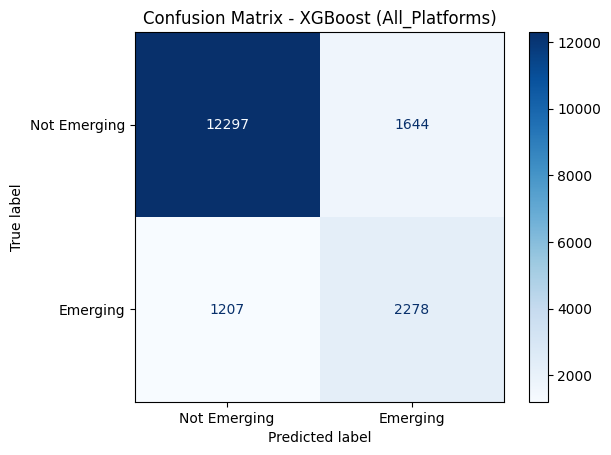

In [ ]:
cm = confusion_matrix(y_test, test_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Emerging", "Emerging"]
)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - XGBoost ({best_name})")
plt.show()